In [1]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Preprocessing & pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [2]:
#Feature building for X 
import pandas as pd
import numpy as np

# 1. Chargement du dataset
data = pd.read_csv("Fraud_dataset.csv")

# 2. Initialisation de notre liste de features
features_selectionnees = []

# 3. Boucle d'analyse des colonnes
for col in data.columns:
    # On ignore la cible (le label à prédire) et les IDs
    if col in ["Fraud_Label", "Transaction_ID", "User_ID"]:
        continue
    
    # Vérification : est-ce que la colonne est de type numérique ?
    if pd.api.types.is_numeric_dtype(data[col]):
        features_selectionnees.append(col)
        print(f"✅ Ajout de la feature numérique : {col}")
    else:
        print(f"❌ Colonne ignorée (non-numérique) : {col}")

# 4. Construction de X final
X = data[features_selectionnees]

print(f"\nDimensions finales de X : {X.shape}")
print(X.head())

✅ Ajout de la feature numérique : Transaction_Amount
❌ Colonne ignorée (non-numérique) : Transaction_Type
❌ Colonne ignorée (non-numérique) : Timestamp
✅ Ajout de la feature numérique : Account_Balance
❌ Colonne ignorée (non-numérique) : Device_Type
❌ Colonne ignorée (non-numérique) : Location
❌ Colonne ignorée (non-numérique) : Merchant_Category
✅ Ajout de la feature numérique : IP_Address_Flag
✅ Ajout de la feature numérique : Previous_Fraudulent_Activity
✅ Ajout de la feature numérique : Daily_Transaction_Count
✅ Ajout de la feature numérique : Avg_Transaction_Amount_7d
✅ Ajout de la feature numérique : Failed_Transaction_Count_7d
❌ Colonne ignorée (non-numérique) : Card_Type
✅ Ajout de la feature numérique : Card_Age
✅ Ajout de la feature numérique : Transaction_Distance
❌ Colonne ignorée (non-numérique) : Authentication_Method
✅ Ajout de la feature numérique : Risk_Score
✅ Ajout de la feature numérique : Is_Weekend

Dimensions finales de X : (50000, 11)
   Transaction_Amount  Acco

In [3]:

# Reproducibility
SEED = 42

# Dataset loading 
data = pd.read_csv("Fraud_dataset.csv")

Y = data["Fraud_Label"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=SEED
)

# Pipeline models 

models = {
    "Logistic Regression": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=SEED)),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight={0:1, 1:5}
        ))
    ]),

    "Random Forest": ImbPipeline([
        ("smote", SMOTE(random_state=SEED)),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        ))
    ])
}

# Validation matrix 

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []
all_scores_recall = [] # utile pour l`affichage graphique
names = []
for name, model in models.items():
    cv_results = cross_validate(
        model, 
        X_train, 
        Y_train, 
        cv=cv, 
        scoring=scoring, 
        n_jobs=-1
    )
    
    # on stocke les scores bruts pour le boxplot (ex: les 5 scores du Recall)
    all_scores_recall.append(cv_results["test_recall"])
    names.append("LR" if "Logistic" in name else "RF")
    #
    results.append({
        "Model": name,
        "ROC-AUC": cv_results["test_roc_auc"].mean(),
        "Avg Precision": cv_results["test_avg_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "F1": cv_results["test_f1"].mean()
    })
results_df = pd.DataFrame(results).set_index("Model")
print(results_df)

                     ROC-AUC  Avg Precision    Recall  Precision        F1
Model                                                                     
Logistic Regression  0.89895        0.81689  0.999144   0.537012  0.698556
Random Forest        1.00000        1.00000  1.000000   0.996674  0.998332


/tmp/ipykernel_17392/3740421898.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_scores_recall, labels=names)


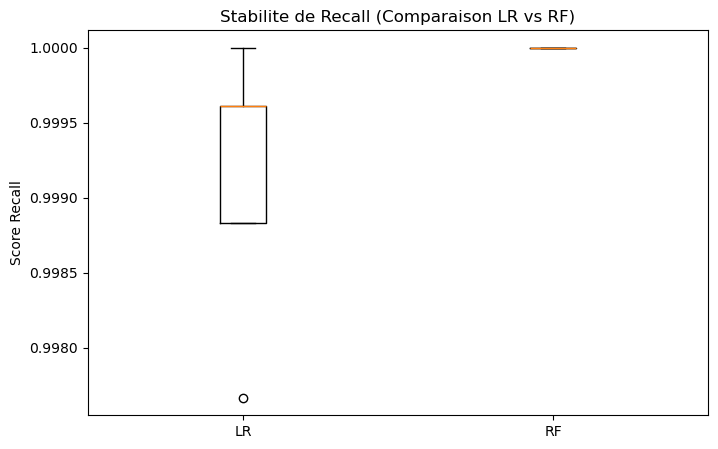

In [4]:
# Graphic for models comparaison
plt.figure(figsize=(8, 5))
plt.boxplot(all_scores_recall, labels=names)
plt.title('Stabilite de Recall (Comparaison LR vs RF)')
plt.ylabel('Score Recall')
plt.show()
